# VIX vs. Realized S&P 500 Volatility

**Goal:** compare the VIX (implied, forward-looking 30-day vol) against realized S&P 500 volatility, and visualize the volatility risk premium.

- `^VIX` is quoted in *annualized percentage points* (e.g. 20 means 20%/yr).
- We'll express realized vol on the same scale so they're directly comparable.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

START, END = "2010-01-01", None  # None => up to today

data = yf.download(["^GSPC", "^VIX"], start=START, end=END, auto_adjust=True, progress=False)
close = data["Close"].dropna()
close.columns = ["sp500", "vix"]
close.tail()

,sp500,vix
Date,,
2026-05-12,7400.959961,17.990000
2026-05-13,7444.250000,17.870001
2026-05-14,7501.240234,17.260000
2026-05-15,7408.500000,18.430000
2026-05-18,7403.049805,17.820000


In [2]:
def realized_vol(prices: pd.Series, window: int = 21) -> pd.Series:
    """
    Rolling annualized realized volatility, in % (same scale as VIX).
    """
    log_returns = np.log(prices / prices.shift(1))
    return log_returns.ewm(span=21).std() * np.sqrt(252) * 100


rv = realized_vol(close["sp500"], window=21)
rv.tail()

Date
2026-05-12    11.561976
2026-05-13    11.098757
2026-05-14    10.771229
2026-05-15    12.751084
2026-05-18    12.237708
Name: sp500, dtype: float64

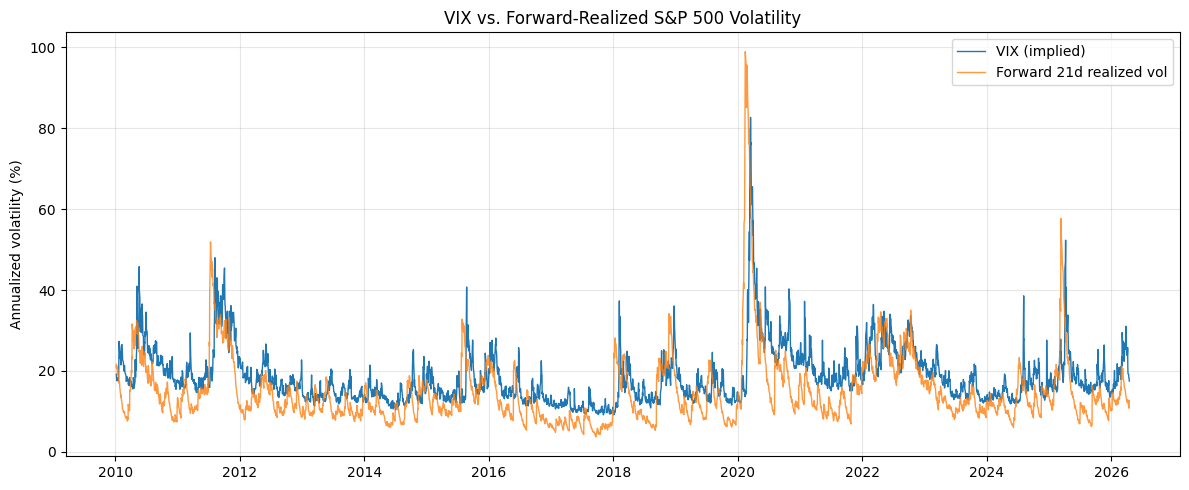

In [3]:
# Align: compare today's VIX with the *forward* 21-day realized vol.
# shift(-21) brings the future window's RV back to today's timestamp.
df = pd.DataFrame(
    {
        "vix": close["vix"],
        "rv_backward": rv,  # realized over the past 21d (ends today)
        "rv_forward": rv.shift(-21),  # realized over the next 21d (what VIX predicted)
    }
).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df["vix"], label="VIX (implied)", linewidth=1)
ax.plot(df.index, df["rv_forward"], label="Forward 21d realized vol", linewidth=1, alpha=0.8)
ax.set_ylabel("Annualized volatility (%)")
ax.set_title("VIX vs. Forward-Realized S&P 500 Volatility")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Mean VIX:            18.45
Mean forward RV:     14.90
Mean VRP (VIX - RV): 3.55
Correlation:         0.598


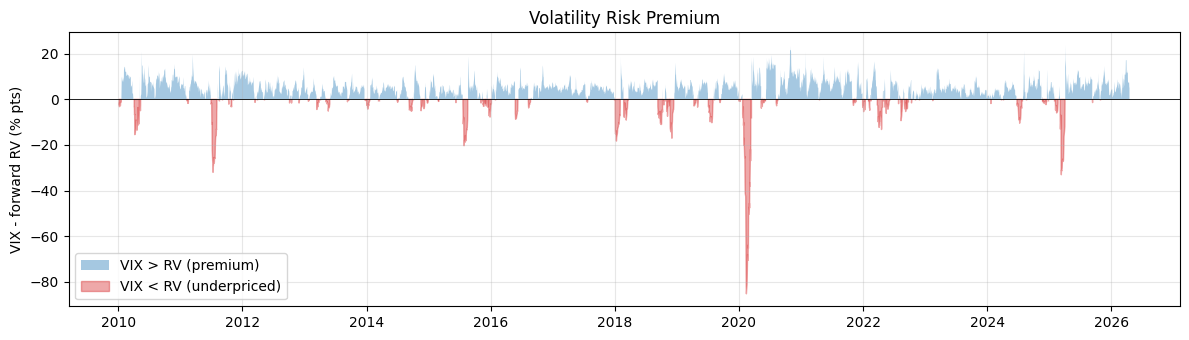

In [4]:
# Volatility risk premium: VIX - forward-realized vol.
# Persistently positive => VIX systematically overprices risk (the "VRP").
premium = df["vix"] - df["rv_forward"]

print(f"Mean VIX:            {df['vix'].mean():.2f}")
print(f"Mean forward RV:     {df['rv_forward'].mean():.2f}")
print(f"Mean VRP (VIX - RV): {premium.mean():.2f}")
print(f"Correlation:         {df['vix'].corr(df['rv_forward']):.3f}")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.fill_between(
    premium.index, premium, 0, where=premium >= 0, alpha=0.4, label="VIX > RV (premium)"
)
ax.fill_between(
    premium.index,
    premium,
    0,
    where=premium < 0,
    alpha=0.4,
    color="C3",
    label="VIX < RV (underpriced)",
)
ax.axhline(0, color="k", linewidth=0.6)
ax.set_ylabel("VIX - forward RV (% pts)")
ax.set_title("Volatility Risk Premium")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()